In [1]:
# Cell 1 — Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Cell 2 — Load Data from MySQL
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='sqlroot@02',
    database='ipl_db'
)

matches = pd.read_sql("SELECT * FROM matches", conn)
deliveries = pd.read_sql("SELECT * FROM deliveries", conn)

print(f"Matches: {matches.shape}")
print(f"Deliveries: {deliveries.shape}")
matches.head()

C:\Users\Veera Reddy\AppData\Local\Temp\ipykernel_14684\1081076410.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  matches = pd.read_sql("SELECT * FROM matches", conn)
C:\Users\Veera Reddy\AppData\Local\Temp\ipykernel_14684\1081076410.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  deliveries = pd.read_sql("SELECT * FROM deliveries", conn)


Matches: (1076, 20)
Deliveries: (170170, 17)


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140,223,20,N,NA,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33,241,20,N,NA,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9,130,20,N,NA,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5,166,20,N,NA,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5,111,20,N,NA,BF Bowden,K Hariharan


In [3]:
# Cell 3 — Data Cleaning
print("Missing values in matches:")
print(matches.isnull().sum())

print("\nMissing values in deliveries:")
print(deliveries.isnull().sum())

print("\nDuplicates in matches:", matches.duplicated().sum())
print("Duplicates in deliveries:", deliveries.duplicated().sum())

# Convert runs columns to numeric
deliveries['batsman_runs'] = pd.to_numeric(deliveries['batsman_runs'], errors='coerce')
deliveries['total_runs'] = pd.to_numeric(deliveries['total_runs'], errors='coerce')

print("\nData cleaning done!")

Missing values in matches:
id                 0
season             0
city               0
date               0
match_type         0
player_of_match    0
venue              0
team1              0
team2              0
toss_winner        0
toss_decision      0
winner             0
result             0
result_margin      0
target_runs        0
target_overs       0
super_over         0
method             0
umpire1            0
umpire2            0
dtype: int64

Missing values in deliveries:
match_id            0
inning              0
batting_team        0
bowling_team        0
over                0
ball                0
batter              0
bowler              0
non_striker         0
batsman_runs        0
extra_runs          0
total_runs          0
extras_type         0
is_wicket           0
player_dismissed    0
dismissal_kind      0
fielder             0
dtype: int64

Duplicates in matches: 0
Duplicates in deliveries: 0

Data cleaning done!


C:\Users\Veera Reddy\AppData\Local\Temp\ipykernel_14684\3783242076.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_batsmen.values, y=top_batsmen.index, palette='OrRd_r')


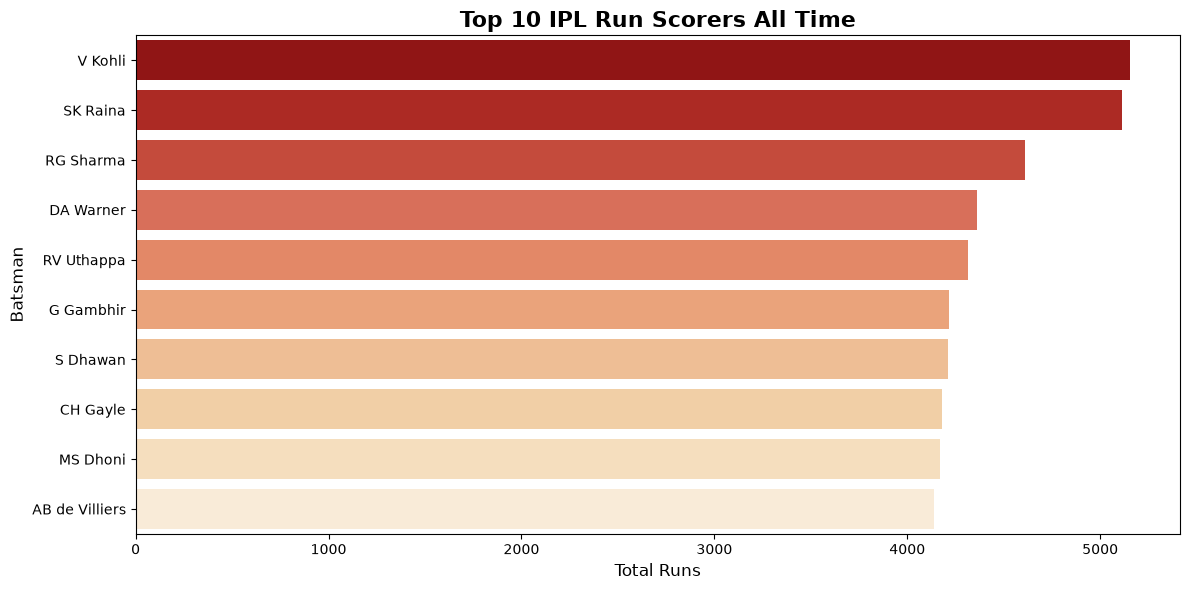

Chart saved!


In [4]:
# Cell 4 — Top 10 Run Scorers Chart
top_batsmen = deliveries.groupby('batter')['batsman_runs'].sum()\
              .sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_batsmen.values, y=top_batsmen.index, palette='OrRd_r')
plt.title('Top 10 IPL Run Scorers All Time', fontsize=16, fontweight='bold')
plt.xlabel('Total Runs', fontsize=12)
plt.ylabel('Batsman', fontsize=12)
plt.tight_layout()
plt.savefig('top_batsmen.png')
plt.show()
print("Chart saved!")

C:\Users\Veera Reddy\AppData\Local\Temp\ipykernel_14684\3459479874.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='toss_decision', y='win_percentage', data=toss, palette='Blues_d')


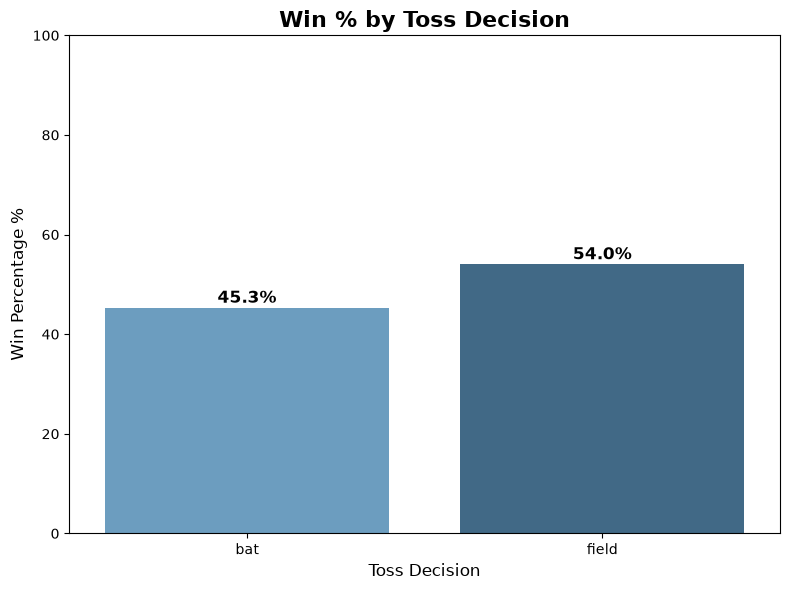

Chart saved!


In [5]:
# Cell 5 — Toss Impact Analysis
toss = matches.groupby('toss_decision').apply(
    lambda x: (x['toss_winner'] == x['winner']).sum() / len(x) * 100
).reset_index()
toss.columns = ['toss_decision', 'win_percentage']

plt.figure(figsize=(8, 6))
sns.barplot(x='toss_decision', y='win_percentage', data=toss, palette='Blues_d')
plt.title('Win % by Toss Decision', fontsize=16, fontweight='bold')
plt.xlabel('Toss Decision', fontsize=12)
plt.ylabel('Win Percentage %', fontsize=12)
plt.ylim(0, 100)
for i, v in enumerate(toss['win_percentage']):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('toss_analysis.png')
plt.show()
print("Chart saved!")

C:\Users\Veera Reddy\AppData\Local\Temp\ipykernel_14684\1640837373.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=wickets.values, y=wickets.index, palette='Greens_r')


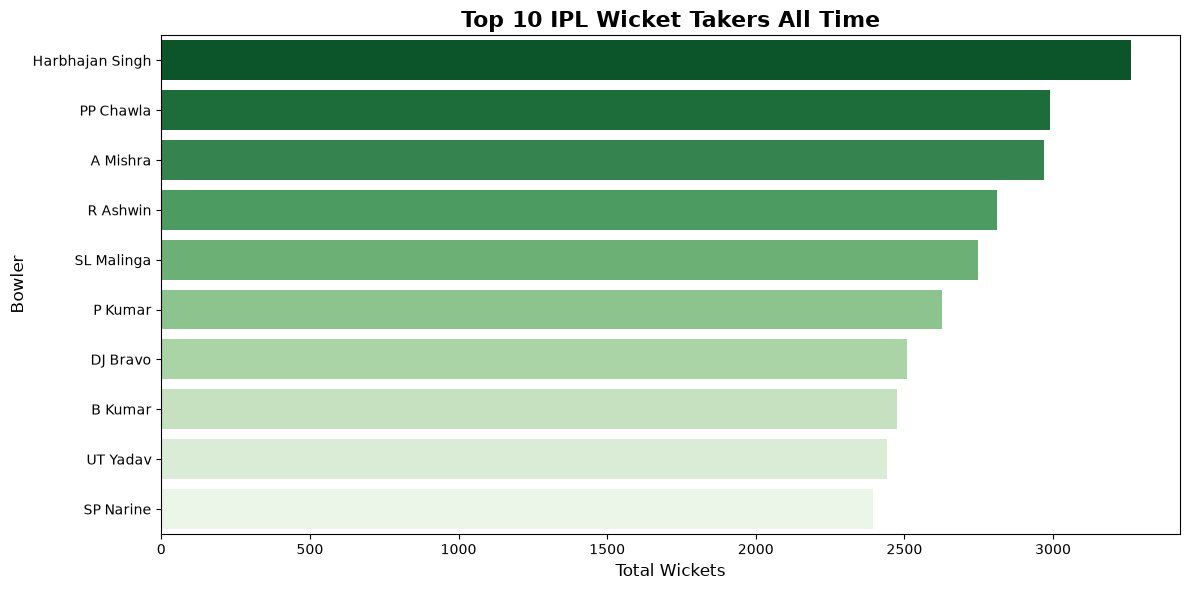

Chart saved!


In [6]:
# Cell 6 — Top 10 Wicket Takers
wickets = deliveries[
    (deliveries['dismissal_kind'].notna()) &
    (deliveries['dismissal_kind'] != '') &
    (~deliveries['dismissal_kind'].isin(['run out', 'retired hurt', 'obstructing the field']))
].groupby('bowler')['dismissal_kind'].count()\
 .sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=wickets.values, y=wickets.index, palette='Greens_r')
plt.title('Top 10 IPL Wicket Takers All Time', fontsize=16, fontweight='bold')
plt.xlabel('Total Wickets', fontsize=12)
plt.ylabel('Bowler', fontsize=12)
plt.tight_layout()
plt.savefig('top_wickets.png')
plt.show()
print("Chart saved!")

C:\Users\Veera Reddy\AppData\Local\Temp\ipykernel_14684\3076889219.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='value_score', y='batter', data=batting, palette='plasma')


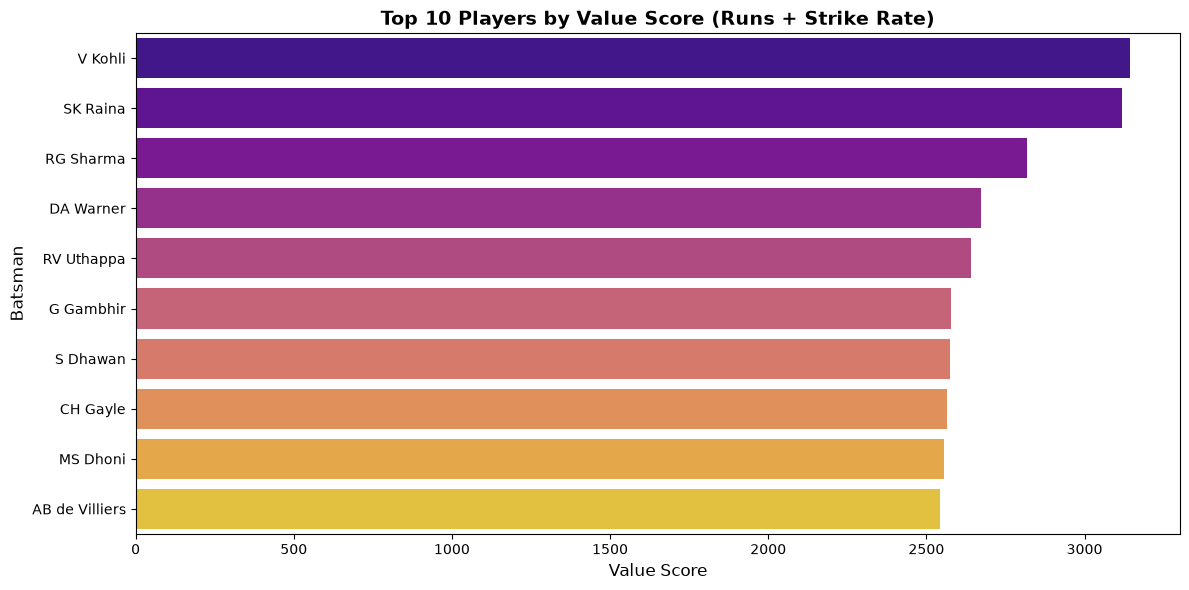

Chart saved!


In [7]:
# Cell 7 — Player Value Score (Unique Insight)
batting = deliveries.groupby('batter').agg(
    total_runs=('batsman_runs', 'sum'),
    balls_faced=('ball', 'count')
).reset_index()

batting['strike_rate'] = (batting['total_runs'] / batting['balls_faced']) * 100
batting['value_score'] = (batting['total_runs'] * 0.6) + (batting['strike_rate'] * 0.4)
batting = batting[batting['total_runs'] >= 500].sort_values('value_score', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x='value_score', y='batter', data=batting, palette='plasma')
plt.title('Top 10 Players by Value Score (Runs + Strike Rate)', fontsize=14, fontweight='bold')
plt.xlabel('Value Score', fontsize=12)
plt.ylabel('Batsman', fontsize=12)
plt.tight_layout()
plt.savefig('player_value_score.png')
plt.show()
print("Chart saved!")

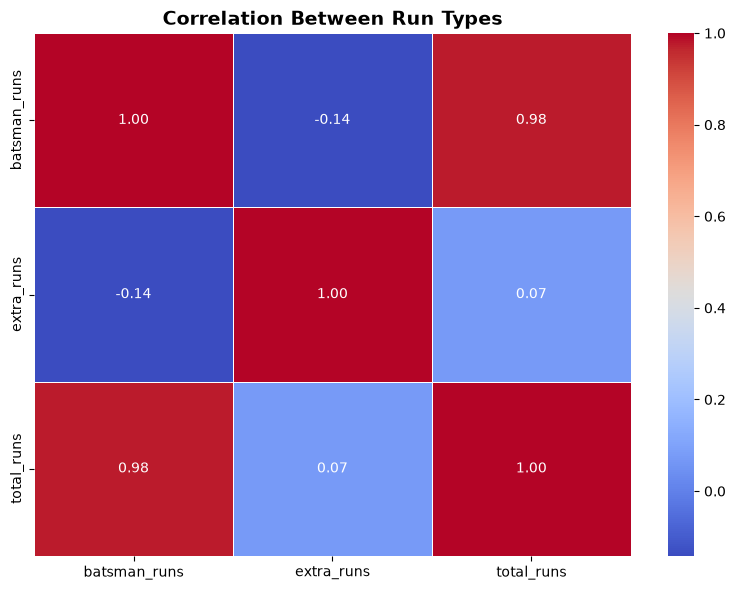

Chart saved!


In [8]:
# Cell 8 — Correlation Heatmap
numeric_cols = deliveries[['batsman_runs', 'extra_runs', 'total_runs']].copy()
numeric_cols = numeric_cols.apply(pd.to_numeric, errors='coerce')

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_cols.corr(), 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            linewidths=0.5)
plt.title('Correlation Between Run Types', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()
print("Chart saved!")

In [9]:
# Cell 9 — Export data for Power BI
matches.to_csv('matches_clean.csv', index=False)
deliveries.to_csv('deliveries_clean.csv', index=False)
print("Files exported for Power BI!")
print(f"Saved to your Desktop folder")

Files exported for Power BI!
Saved to your Desktop folder


In [10]:
import os
print("Current directory:", os.getcwd())
print("\nFiles in current directory:")
for f in os.listdir():
    if f.endswith('.csv') or f.endswith('.png'):
        print(f)

Current directory: C:\Users\Veera Reddy

Files in current directory:
correlation_heatmap.png
deliveries_clean.csv
matches_clean.csv
player_value_score.png
top_batsmen.png
top_wickets.png
toss_analysis.png
